# **Model 3**

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,210 (1.55 MB)

 Trainable params: 407,210 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 103s 75ms/step - accuracy: 0.3675 - loss: 1.6621 - val_accuracy: 0.5637 - val_loss: 1.2406
Epoch 2/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 132s 68ms/step - accuracy: 0.5155 - loss: 1.3220 - val_accuracy: 0.6822 - val_loss: 0.9538
Epoch 3/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.5721 - loss: 1.1748 - val_accuracy: 0.6543 - val_loss: 0.9688
Epoch 4/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 85s 62ms/step - accuracy: 0.6119 - loss: 1.0778 - val_accuracy: 0.7356 - val_loss: 0.7539
Epoch 5/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.6444 - loss: 1.0114 - val_accuracy: 0.7261 - val_loss: 0.7970
Evaluating model on validation set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


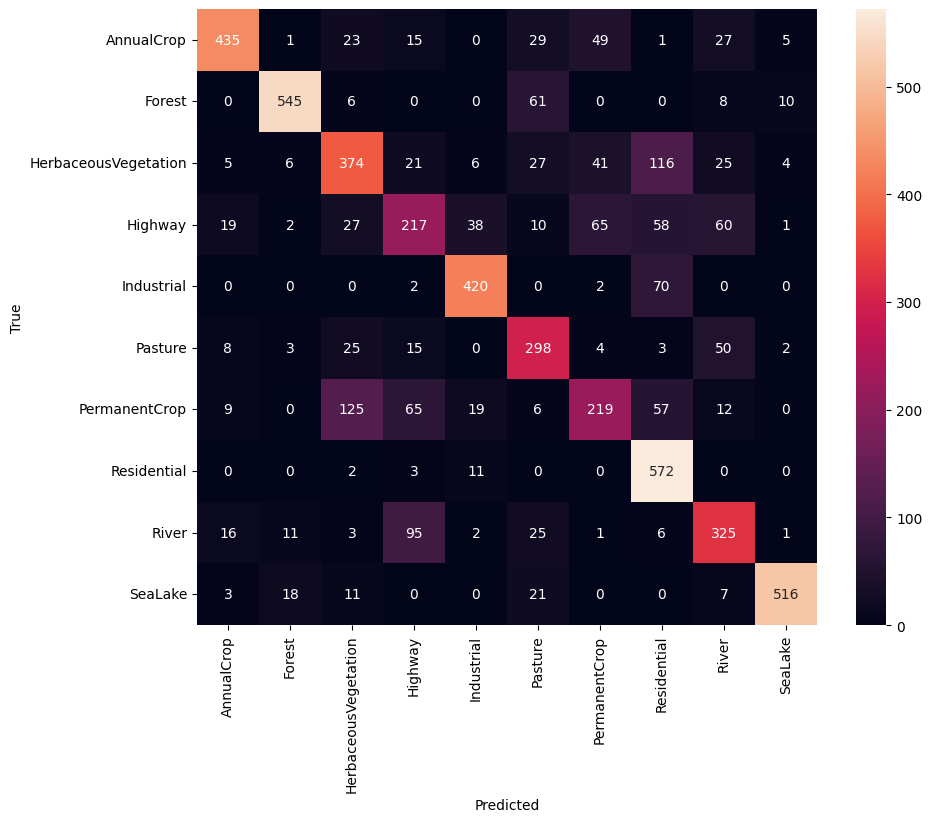

                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.74      0.81       585
              Forest       0.93      0.87      0.90       630
HerbaceousVegetation       0.63      0.60      0.61       625
             Highway       0.50      0.44      0.47       497
          Industrial       0.85      0.85      0.85       494
             Pasture       0.62      0.73      0.67       408
       PermanentCrop       0.57      0.43      0.49       512
         Residential       0.65      0.97      0.78       588
               River       0.63      0.67      0.65       485
             SeaLake       0.96      0.90      0.93       576

            accuracy                           0.73      5400
           macro avg       0.72      0.72      0.71      5400
        weighted avg       0.73      0.73      0.72      5400



In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub


path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

data_dir = os.path.join(path, 'EuroSAT')

IMG_SIZE = (64, 64)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=26,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=26,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")


num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure val_ds and model exist before running
try:
    # Get labels and predictions for validation set
    y_true = []
    y_pred = []
    print("Evaluating model on validation set...")
    for x, y in val_ds:
        y_true.extend(y.numpy())
        preds = model.predict(x, verbose=1)
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))
except NameError as e:
    print(f"Error: {e}. Run the Data Loading (Step 1) and Training (Step 3) cells first.")